# 06 — Sleep Quality Baseline

Establishes a personal sleep baseline for QuantifiedStrides.
Reads from `data/sleep.parquet` (run notebook 00 first).

**What this notebook builds:**
- Rolling 30-day personal z-scores for each sleep signal
- Architecture score (duration, deep ratio, REM ratio)
- Stress score (sleep stress, overnight RHR, respiration rate)
- Ridge regression: today's sleep → tomorrow's HRV z-score (80/20 chronological split)
- Stability test: coefficient robustness under 30% simulated missingness
- `compute_sleep_readiness()` output contract — three-path design for the recommendation engine

**Prerequisites:** `data/sleep.parquet`, `data/daily_signals.parquet` (from notebook 00 with the date-range fix applied)

**Primary deliverable:** the algorithm and scaffolding. With ~498 nights the Ridge model is powered;
the composite weights are updated from literature defaults to data-derived Ridge coefficients once the model is validated.

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import shapiro, pearsonr
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
import config

DATA_DIR           = config.DATA_DIR
SLEEP_PATH         = os.path.join(DATA_DIR, 'sleep.parquet')
DAILY_SIGNALS_PATH = os.path.join(DATA_DIR, 'daily_signals.parquet')

# ── Constants (configurable — review before each re-run) ──────────────────
ROLLING_WINDOW               = 30    # days — trailing window for personal z-scores
MIN_PERIODS                  = 7     # minimum nights to compute a z-score
DATA_CONFIDENCE_THRESHOLD    = 0.50  # below this → sleep modifier excluded (Path B/C)
ARCHITECTURE_WEIGHT          = 0.60  # literature prior; replaced by Ridge coefs once validated
STRESS_WEIGHT                = 0.40
ZERO_REM_DURATION_THRESHOLD  = 3.0   # hours: rem=0 with duration>3h = Garmin failure
MIN_SLEEP_DURATION_H         = 1.0   # below this = not a real sleep night
OUTLIER_SIGMA                = 1.5   # z-score threshold for session anomaly flagging

# Ridge model
RIDGE_ALPHAS  = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
TRAIN_FRAC    = 0.80

# Stability test
N_STABILITY_TRIALS = 50
STABILITY_DROP_FRAC = 0.30  # fraction of training nights randomly removed per trial

print('Config loaded.')
print(f'  SLEEP_PATH         : {SLEEP_PATH}')
print(f'  DAILY_SIGNALS_PATH : {DAILY_SIGNALS_PATH}')

Config loaded.
  SLEEP_PATH         : C:\Users\vasiu\UBB\Quantified-Strides\data\sleep.parquet
  DAILY_SIGNALS_PATH : C:\Users\vasiu\UBB\Quantified-Strides\data\daily_signals.parquet


## 1. Data Quality

Three issues to resolve before any modelling:
1. **Zero-REM nights** — `rem_h == 0` with `duration > 3h` is a Garmin stage-classification failure, not true REM-absent sleep
2. **`sleep_stress` outliers** — right-skewed with a 84+ outlier; log-transform before z-scoring
3. **Missing nights** — not imputed as zero; tracked via `data_confidence` metric

In [2]:
# ── Load data ─────────────────────────────────────────────────────────────
df_sleep  = pd.read_parquet(SLEEP_PATH)
df_daily  = pd.read_parquet(DAILY_SIGNALS_PATH)

df_sleep['date'] = pd.to_datetime(df_sleep['date'])
df_daily['date'] = pd.to_datetime(df_daily['date'])

# Drop nights below minimum duration threshold (partial recordings, failed syncs)
n_before = len(df_sleep)
df_sleep = df_sleep[df_sleep['sleep_duration_h'] >= MIN_SLEEP_DURATION_H].copy()
print(f'Nights loaded    : {n_before}')
print(f'After min-duration filter ({MIN_SLEEP_DURATION_H}h): {len(df_sleep)}')
print(f'Date range       : {df_sleep["date"].min().date()} → {df_sleep["date"].max().date()}')
print()
print(df_sleep[['sleep_duration_h','deep_h','rem_h','sleep_score',
                'sleep_stress','sleep_respiration']].describe().round(3))

Nights loaded    : 497
After min-duration filter (1.0h): 496
Date range       : 2024-07-07 → 2026-04-18

       sleep_duration_h   deep_h    rem_h  sleep_score  sleep_stress  \
count           496.000  496.000  496.000      496.000       496.000   
mean              6.852    1.436    1.236       74.413        16.392   
std               1.821    0.521    0.651       19.313        13.649   
min               1.317    0.000    0.000        8.000         3.610   
25%               5.762    1.067    0.779       67.000         9.487   
50%               7.042    1.417    1.217       79.000        12.180   
75%               8.088    1.783    1.717       89.000        17.285   
max              10.633    3.333    3.200      100.000        84.470   

       sleep_respiration  
count            494.000  
mean              13.345  
std                1.118  
min               11.000  
25%               13.000  
50%               13.000  
75%               13.740  
max               22.000  


Zero-REM nights with duration > 3.0h: 8 → rem_h nulled out
rem_h coverage after treatment: 488 / 496

sleep_stress: median=12.2, p75=17.3, 3×IQR fence=40.7
Nights above 3×IQR fence: 32
  Values: [np.float64(84.47000122070312), np.float64(84.37999725341797), np.float64(83.62999725341797), np.float64(79.38999938964844), np.float64(78.27999877929688), np.float64(75.97000122070312), np.float64(75.68000030517578), np.float64(74.51000213623047), np.float64(73.06999969482422), np.float64(72.2699966430664), np.float64(71.75), np.float64(69.73999786376953), np.float64(64.47000122070312), np.float64(64.27999877929688), np.float64(61.97999954223633), np.float64(61.459999084472656), np.float64(59.22999954223633), np.float64(57.060001373291016), np.float64(55.459999084472656), np.float64(55.349998474121094), np.float64(53.66999816894531), np.float64(53.130001068115234), np.float64(51.2599983215332), np.float64(48.70000076293945), np.float64(48.63999938964844), np.float64(48.470001220703125), np.flo

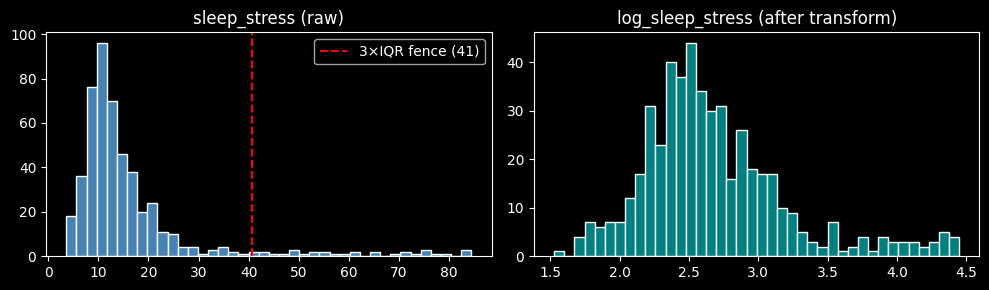

In [3]:
# ── Zero-REM detection ────────────────────────────────────────────────────
# rem_h == 0 with duration > 3h: Garmin failed to classify sleep stages.
# True zero-REM at this duration would require a clinical condition (narcolepsy, severe apnea).
# Treatment: null out rem_h for these nights only — duration and deep_h remain valid.
zero_rem_mask = (df_sleep['rem_h'] == 0) & (df_sleep['sleep_duration_h'] > ZERO_REM_DURATION_THRESHOLD)
n_zero_rem = zero_rem_mask.sum()
df_sleep.loc[zero_rem_mask, 'rem_h'] = np.nan

print(f'Zero-REM nights with duration > {ZERO_REM_DURATION_THRESHOLD}h: {n_zero_rem} → rem_h nulled out')
print(f'rem_h coverage after treatment: {df_sleep["rem_h"].notna().sum()} / {len(df_sleep)}')

# ── sleep_stress distribution + log transform ─────────────────────────────
stress = df_sleep['sleep_stress'].dropna()
q1, q3 = stress.quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence_3iqr = q3 + 3 * iqr
n_outliers = (stress > upper_fence_3iqr).sum()

print(f'\nsleep_stress: median={stress.median():.1f}, p75={q3:.1f}, 3×IQR fence={upper_fence_3iqr:.1f}')
print(f'Nights above 3×IQR fence: {n_outliers}')
if n_outliers > 0:
    print(f'  Values: {sorted(stress[stress > upper_fence_3iqr].values, reverse=True)}')

# log1p handles zeros; after transform the outlier compresses to a manageable range
df_sleep['log_sleep_stress'] = np.log1p(df_sleep['sleep_stress'])
print(f'\nlog_sleep_stress: mean={df_sleep["log_sleep_stress"].mean():.3f}, '
      f'std={df_sleep["log_sleep_stress"].std():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(stress.dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(upper_fence_3iqr, color='red', linestyle='--', label=f'3×IQR fence ({upper_fence_3iqr:.0f})')
axes[0].set_title('sleep_stress (raw)')
axes[0].legend()
axes[1].hist(df_sleep['log_sleep_stress'].dropna(), bins=40, color='teal', edgecolor='white')
axes[1].set_title('log_sleep_stress (after transform)')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'sleep_stress_distribution.png'), dpi=120, bbox_inches='tight')
plt.show()

Total nights in date range : 651
Nights with sleep data     : 496  (76.2%)
Missing nights             : 155  (23.8%)

Data confidence (trailing 30d):
  Current           : 0.87
  Mean over history : 0.76
  Below 50% threshold : 107 days


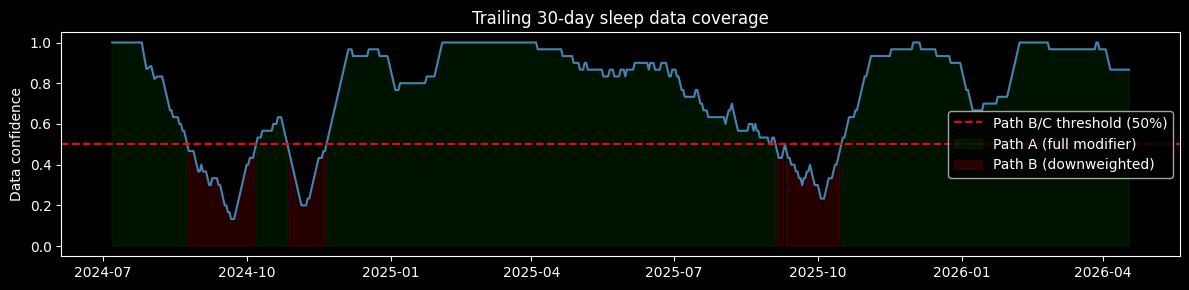

In [4]:
# ── Missing nights analysis + data_confidence ─────────────────────────────
# Missing nights are tracked but never imputed as zero — imputing zero would make
# the rolling mean look like chronic sleep deprivation.
full_index = pd.DataFrame({'date': pd.date_range(df_sleep['date'].min(), df_sleep['date'].max())})
coverage   = full_index.merge(df_sleep[['date']].assign(present=1), on='date', how='left')
n_missing  = coverage['present'].isna().sum()
total      = len(coverage)

print(f'Total nights in date range : {total}')
print(f'Nights with sleep data     : {total - n_missing}  ({100*(total-n_missing)/total:.1f}%)')
print(f'Missing nights             : {n_missing}  ({100*n_missing/total:.1f}%)')

# data_confidence: trailing 30-day coverage fraction
# This drives the three-path output contract (A: >=50%, B: 0-50%, C: 0%)
coverage = coverage.sort_values('date').reset_index(drop=True)
coverage['present_filled'] = coverage['present'].fillna(0)
coverage['data_confidence'] = (
    coverage['present_filled']
    .rolling(ROLLING_WINDOW, min_periods=1)
    .mean()
)

print(f'\nData confidence (trailing {ROLLING_WINDOW}d):')
print(f'  Current           : {coverage["data_confidence"].iloc[-1]:.2f}')
print(f'  Mean over history : {coverage["data_confidence"].mean():.2f}')
print(f'  Below {DATA_CONFIDENCE_THRESHOLD:.0%} threshold : {(coverage["data_confidence"] < DATA_CONFIDENCE_THRESHOLD).sum()} days')

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(coverage['date'], coverage['data_confidence'], color='steelblue', linewidth=1.5)
ax.axhline(DATA_CONFIDENCE_THRESHOLD, color='red', linestyle='--',
           label=f'Path B/C threshold ({DATA_CONFIDENCE_THRESHOLD:.0%})')
ax.fill_between(coverage['date'], coverage['data_confidence'],
                where=coverage['data_confidence'] >= DATA_CONFIDENCE_THRESHOLD,
                alpha=0.15, color='green', label='Path A (full modifier)')
ax.fill_between(coverage['date'], coverage['data_confidence'],
                where=coverage['data_confidence'] < DATA_CONFIDENCE_THRESHOLD,
                alpha=0.15, color='red', label='Path B (downweighted)')
ax.set_ylabel('Data confidence')
ax.set_title(f'Trailing {ROLLING_WINDOW}-day sleep data coverage')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'sleep_data_confidence.png'), dpi=120, bbox_inches='tight')
plt.show()

## 2. Rolling Personal Baselines

30-day trailing window z-scores for each signal, mirroring the HRV z-score implementation
in `intelligence/recovery.py`. Trailing (not centered) window prevents future data leakage.
`min_periods=7` keeps the baseline operational while the window fills.

In [5]:
# ── Join rhr from daily_signals (overnight low HR — a sleep quality signal) ──
df = df_sleep.merge(df_daily[['date', 'rhr', 'hrv', 'hrv_z']], on='date', how='left')
df = df.sort_values('date').reset_index(drop=True)

# ── Compute ratios (EP recommendation: controls for total duration) ────────
df['deep_ratio'] = np.where(
    df['sleep_duration_h'] > 0,
    df['deep_h'] / df['sleep_duration_h'],
    np.nan
)
df['rem_ratio'] = np.where(
    (df['sleep_duration_h'] > 0) & df['rem_h'].notna(),
    df['rem_h'] / df['sleep_duration_h'],
    np.nan
)

# ── Rolling z-scores ──────────────────────────────────────────────────────
# Each z-score: (value - 30d trailing mean) / 30d trailing SD
# Architecture signals (positive orientation — higher = better sleep structure)
ARCH_SIGNALS   = ['sleep_duration_h', 'deep_ratio', 'rem_ratio']
# Stress signals (negative orientation — higher raw value = worse autonomic state)
STRESS_SIGNALS = ['log_sleep_stress', 'rhr', 'sleep_respiration']
ALL_SIGNALS    = ARCH_SIGNALS + STRESS_SIGNALS

for sig in ALL_SIGNALS:
    roll_mean = df[sig].rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean()
    roll_std  = df[sig].rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).std()
    df[f'{sig}_z'] = (df[sig] - roll_mean) / roll_std.replace(0, np.nan)

print('Rolling z-scores computed.')
print(f'Z-score columns: {[f"{s}_z" for s in ALL_SIGNALS]}')
print()
# First meaningful z-score at row MIN_PERIODS-1; fully-populated window at ROLLING_WINDOW-1
z_coverage = df[[f'{s}_z' for s in ALL_SIGNALS]].notna().sum()
print('Non-null z-score counts:')
print(z_coverage.to_string())

Rolling z-scores computed.
Z-score columns: ['sleep_duration_h_z', 'deep_ratio_z', 'rem_ratio_z', 'log_sleep_stress_z', 'rhr_z', 'sleep_respiration_z']

Non-null z-score counts:
sleep_duration_h_z     490
deep_ratio_z           490
rem_ratio_z            482
log_sleep_stress_z     490
rhr_z                  175
sleep_respiration_z    484


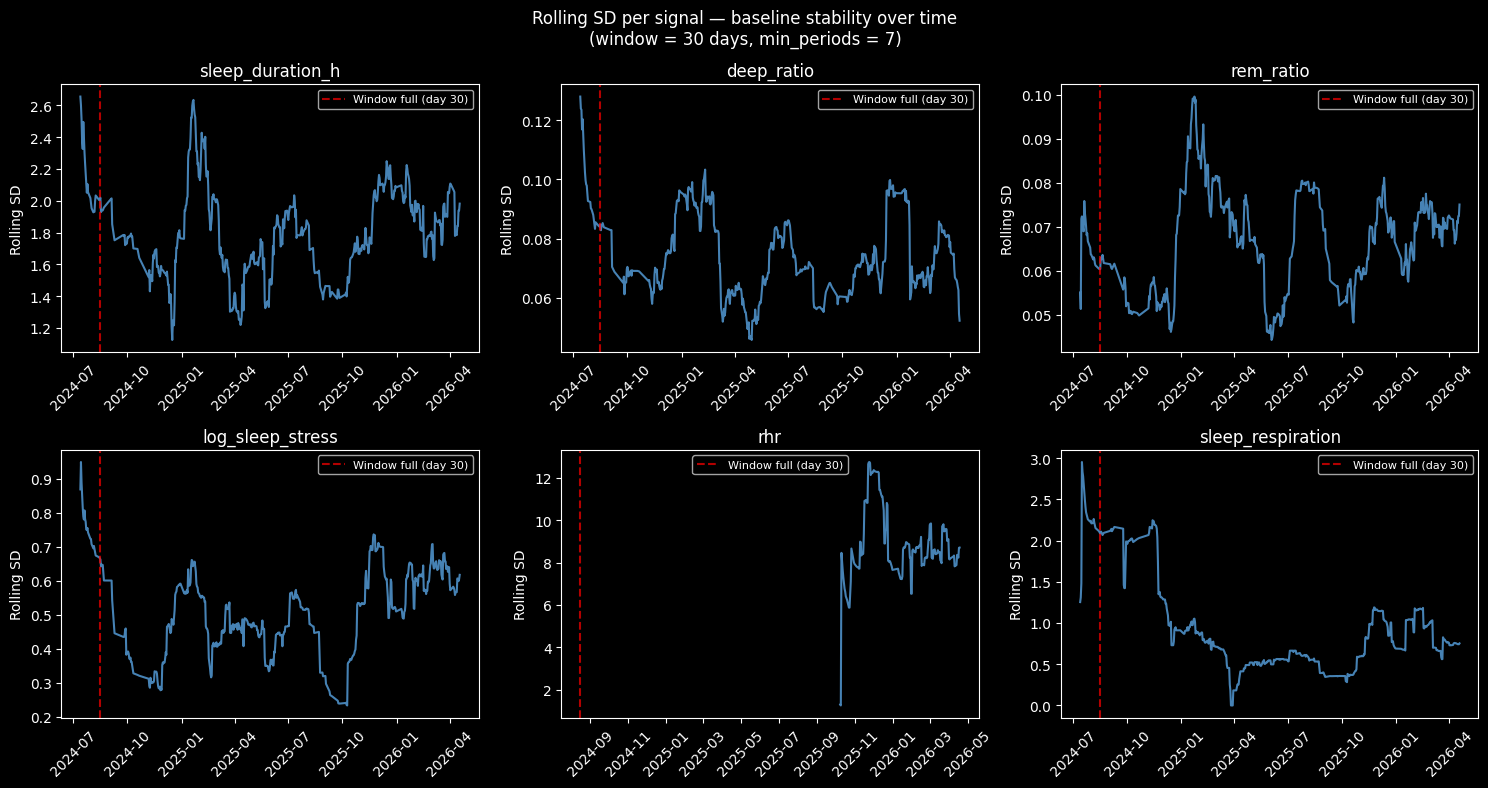

In [6]:
# ── Window-filling stability plot ─────────────────────────────────────────
# Shows when each signal's rolling SD stabilises — the point where the baseline
# is reliable rather than driven by small-sample variance.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, sig in enumerate(ALL_SIGNALS):
    roll_std = df[sig].rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).std()
    axes[i].plot(df['date'], roll_std, color='steelblue', linewidth=1.5)
    # Mark when the window first fills completely
    if len(df) > ROLLING_WINDOW:
        axes[i].axvline(
            df['date'].iloc[ROLLING_WINDOW - 1],
            color='red', linestyle='--', alpha=0.7,
            label=f'Window full (day {ROLLING_WINDOW})'
        )
    axes[i].set_title(sig)
    axes[i].set_ylabel('Rolling SD')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle(
    f'Rolling SD per signal — baseline stability over time\n'
    f'(window = {ROLLING_WINDOW} days, min_periods = {MIN_PERIODS})',
    fontsize=12
)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'sleep_rolling_stability.png'), dpi=120, bbox_inches='tight')
plt.show()

## 3. Architecture & Stress Composites

Two-group frame (EP recommendation):
- **Architecture score**: duration_z, deep_ratio_z, rem_ratio_z — mean (all positively oriented)
- **Stress score**: log_sleep_stress_z, rhr_z, sleep_respiration_z — mean, inverted (higher raw = worse)
- **Sleep readiness**: `0.6 × architecture + 0.4 × stress` (literature weights until Ridge model is validated)

NaN components are excluded from the mean via `skipna=True` (pandas default). The message field
in the output contract reports how many components contributed.

In [7]:
# ── Architecture score ────────────────────────────────────────────────────
arch_z_cols = ['sleep_duration_h_z', 'deep_ratio_z', 'rem_ratio_z']
df['architecture_score'] = df[arch_z_cols].mean(axis=1, skipna=True)

# ── Stress score (invert: higher raw = worse = negative modifier) ─────────
stress_z_cols = ['log_sleep_stress_z', 'rhr_z', 'sleep_respiration_z']
df['stress_score'] = df[stress_z_cols].mul(-1).mean(axis=1, skipna=True)

# ── Sleep readiness composite ─────────────────────────────────────────────
# Weights are literature-derived (ARCHITECTURE_WEIGHT=0.6, STRESS_WEIGHT=0.4).
# After Ridge model validation these are replaced by the data-derived coefficients.
df['sleep_readiness'] = (
    ARCHITECTURE_WEIGHT * df['architecture_score'] +
    STRESS_WEIGHT       * df['stress_score']
)

print('Composite score stats (on rows with valid z-scores):')
valid = df[df['sleep_readiness'].notna()]
print(f'  architecture_score : mean={valid["architecture_score"].mean():.3f}, std={valid["architecture_score"].std():.3f}')
print(f'  stress_score       : mean={valid["stress_score"].mean():.3f}, std={valid["stress_score"].std():.3f}')
print(f'  sleep_readiness    : mean={valid["sleep_readiness"].mean():.3f}, std={valid["sleep_readiness"].std():.3f}')
print(f'  Nights with valid score: {len(valid)} / {len(df)}')

# Correlation between the two groups (should be moderate — they measure related but distinct constructs)
valid_both = df[df['architecture_score'].notna() & df['stress_score'].notna()]
r, p = pearsonr(valid_both['architecture_score'], valid_both['stress_score'])
print(f'\nArchitecture ↔ Stress correlation: r={r:.3f}, p={p:.3f}')
print('(Expected: moderate positive — good sleep architecture tends to accompany low stress)')

Composite score stats (on rows with valid z-scores):
  architecture_score : mean=-0.001, std=0.613
  stress_score       : mean=-0.014, std=0.825
  sleep_readiness    : mean=-0.006, std=0.628
  Nights with valid score: 490 / 496

Architecture ↔ Stress correlation: r=0.616, p=0.000
(Expected: moderate positive — good sleep architecture tends to accompany low stress)


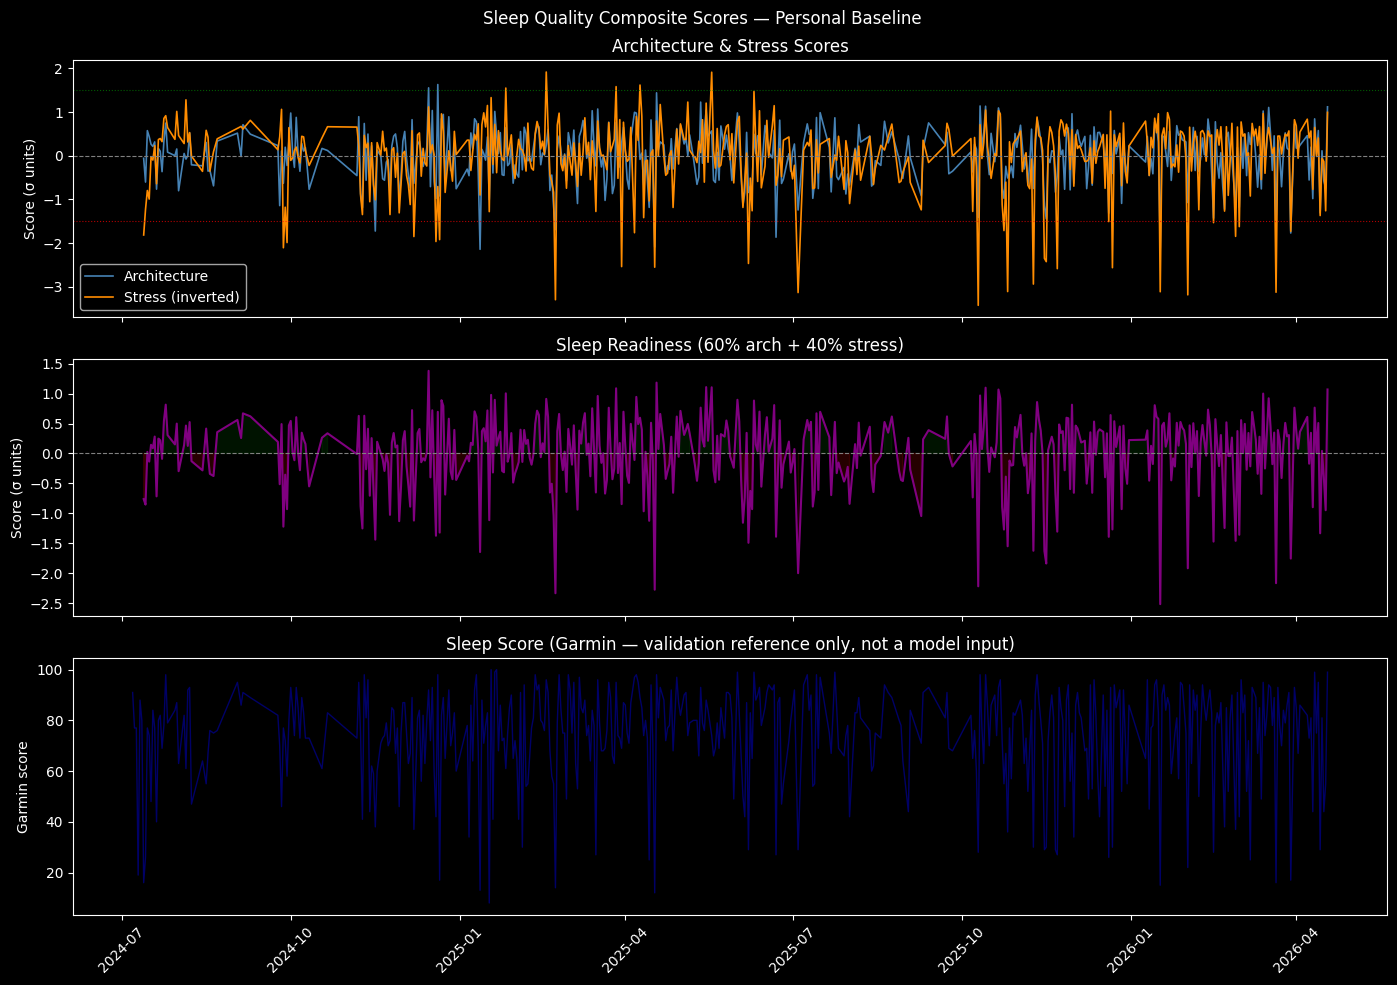

In [8]:
# ── Time series plot of composite scores ─────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Architecture and stress
axes[0].plot(df['date'], df['architecture_score'], color='steelblue', linewidth=1.2, label='Architecture')
axes[0].plot(df['date'], df['stress_score'], color='darkorange', linewidth=1.2, label='Stress (inverted)')
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].axhline(-OUTLIER_SIGMA, color='red', linewidth=0.8, linestyle=':', alpha=0.7)
axes[0].axhline(OUTLIER_SIGMA, color='green', linewidth=0.8, linestyle=':', alpha=0.7)
axes[0].set_ylabel('Score (σ units)')
axes[0].legend()
axes[0].set_title('Architecture & Stress Scores')

# Sleep readiness
axes[1].plot(df['date'], df['sleep_readiness'], color='purple', linewidth=1.5)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].fill_between(df['date'], df['sleep_readiness'], 0,
                     where=df['sleep_readiness'] > 0, alpha=0.15, color='green')
axes[1].fill_between(df['date'], df['sleep_readiness'], 0,
                     where=df['sleep_readiness'] < 0, alpha=0.15, color='red')
axes[1].set_ylabel('Score (σ units)')
axes[1].set_title(f'Sleep Readiness ({ARCHITECTURE_WEIGHT:.0%} arch + {STRESS_WEIGHT:.0%} stress)')

# Sleep score for context
axes[2].plot(df['date'], df['sleep_score'], color='navy', linewidth=1.0, alpha=0.8)
axes[2].set_ylabel('Garmin score')
axes[2].set_title('Sleep Score (Garmin — validation reference only, not a model input)')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Sleep Quality Composite Scores — Personal Baseline', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'sleep_composite_scores.png'), dpi=120, bbox_inches='tight')
plt.show()

## 4. Ridge Model — Next-Day HRV z-score

Today's sleep signals predict tomorrow's HRV z-score.
HRV z-score is computed in `intelligence/recovery.py` from the same rolling window logic.
Same-night HRV is excluded as a feature to avoid confounding with the target.

**Split:** chronological 80/20 — no shuffle. Time series data must not be shuffled.

**Note:** HRV data only goes back to Sep 2025 (181 days) while sleep goes back to Jul 2024.
The model is fit only on nights where both sleep features AND next-day HRV z-score are non-null.

In [9]:
# ── Feature engineering ───────────────────────────────────────────────────
# Target: next-day HRV z-score (shift hrv_z back by 1 row after chronological sort)
df_model = df.sort_values('date').reset_index(drop=True).copy()
df_model['hrv_z_next'] = df_model['hrv_z'].shift(-1)

FEATURE_COLS = [
    'sleep_duration_h',
    'deep_ratio',
    'rem_ratio',
    'log_sleep_stress',
    'rhr',
    'sleep_respiration',
]

# Drop rows with any null in features or target
model_df = df_model[FEATURE_COLS + ['hrv_z_next', 'date']].dropna().reset_index(drop=True)

print(f'Total nights available      : {len(df)}')
print(f'Nights usable for Ridge     : {len(model_df)}')
print(f'  (requires all 6 features + next-day HRV z-score non-null)')
print(f'Date range (model subset)   : {model_df["date"].min().date()} → {model_df["date"].max().date()}')

Total nights available      : 496
Nights usable for Ridge     : 173
  (requires all 6 features + next-day HRV z-score non-null)
Date range (model subset)   : 2025-10-07 → 2026-04-17


In [10]:
# ── Chronological 80/20 split ─────────────────────────────────────────────
split_idx = int(len(model_df) * TRAIN_FRAC)
train_df  = model_df.iloc[:split_idx]
test_df   = model_df.iloc[split_idx:]

X_train = train_df[FEATURE_COLS].values
y_train = train_df['hrv_z_next'].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df['hrv_z_next'].values

print(f'Train nights : {len(train_df)}  ({train_df["date"].min().date()} → {train_df["date"].max().date()})')
print(f'Test nights  : {len(test_df)}   ({test_df["date"].min().date()} → {test_df["date"].max().date()})')

# Standardize: fit on train only, transform both
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# RidgeCV: 10-fold CV on training set to select alpha
ridge = RidgeCV(alphas=RIDGE_ALPHAS, cv=10, scoring='neg_mean_squared_error')
ridge.fit(X_train_s, y_train)

y_pred = ridge.predict(X_test_s)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
r2     = r2_score(y_test, y_pred)

print(f'\nRidge results:')
print(f'  Best alpha (CV)  : {ridge.alpha_:.4f}')
print(f'  Test RMSE        : {rmse:.4f}')
print(f'  Test R²          : {r2:.4f}')
print(f'\nFeature coefficients (standardized, sorted by |coef|):')
coef_pairs = sorted(zip(FEATURE_COLS, ridge.coef_), key=lambda x: abs(x[1]), reverse=True)
for col, coef in coef_pairs:
    print(f'  {col:30s}  {coef:+.4f}')

Train nights : 138  (2025-10-07 → 2026-03-09)
Test nights  : 35   (2026-03-10 → 2026-04-17)

Ridge results:
  Best alpha (CV)  : 100.0000
  Test RMSE        : 0.8591
  Test R²          : -0.0086

Feature coefficients (standardized, sorted by |coef|):
  sleep_respiration               +0.1403
  log_sleep_stress                -0.0621
  rem_ratio                       -0.0530
  sleep_duration_h                +0.0483
  deep_ratio                      +0.0166
  rhr                             -0.0160


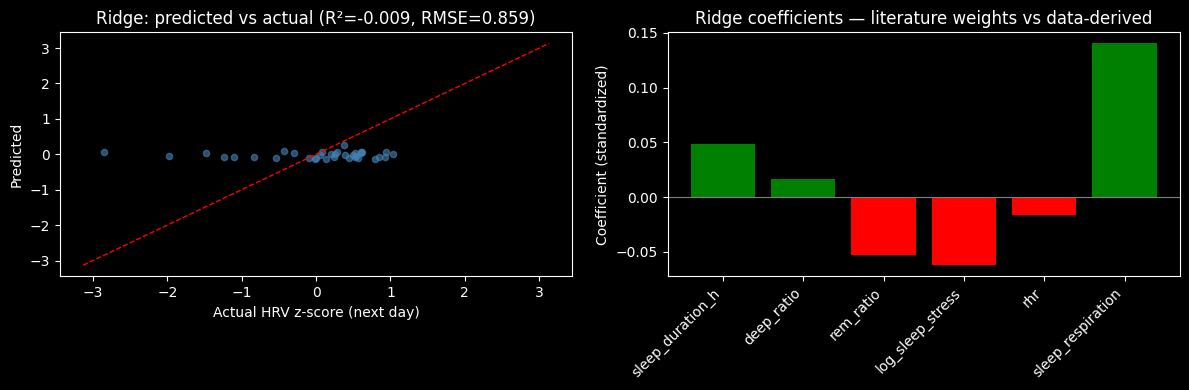


Coefficient sign check (expected vs observed):
  ✓  sleep_duration_h                expected +  got + (+0.0483)
  ✓  deep_ratio                      expected +  got + (+0.0166)
  ✗ UNEXPECTED  rem_ratio                       expected +  got - (-0.0530)
  ✓  log_sleep_stress                expected -  got - (-0.0621)
  ✓  rhr                             expected -  got - (-0.0160)
  ✗ UNEXPECTED  sleep_respiration               expected -  got + (+0.1403)


In [11]:
# ── Predicted vs actual plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', s=20)
lim = max(abs(y_test).max(), abs(y_pred).max()) * 1.1
axes[0].plot([-lim, lim], [-lim, lim], 'r--', linewidth=1)
axes[0].set_xlabel('Actual HRV z-score (next day)')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Ridge: predicted vs actual (R²={r2:.3f}, RMSE={rmse:.3f})')

axes[1].bar(FEATURE_COLS, ridge.coef_, color=['green' if c > 0 else 'red' for c in ridge.coef_])
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_xticklabels(FEATURE_COLS, rotation=45, ha='right')
axes[1].set_ylabel('Coefficient (standardized)')
axes[1].set_title('Ridge coefficients — literature weights vs data-derived')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'sleep_ridge_model.png'), dpi=120, bbox_inches='tight')
plt.show()

# ── Compare Ridge coefficients to literature weights ──────────────────────
# Architecture features should have positive coefficients (more → better HRV tomorrow)
# Stress features should have negative coefficients (more stress → worse HRV tomorrow)
print('\nCoefficient sign check (expected vs observed):')
expected_signs = {
    'sleep_duration_h':  '+',
    'deep_ratio':        '+',
    'rem_ratio':         '+',
    'log_sleep_stress':  '-',
    'rhr':               '-',
    'sleep_respiration': '-',
}
for col, coef in zip(FEATURE_COLS, ridge.coef_):
    obs = '+' if coef > 0 else '-'
    exp = expected_signs[col]
    flag = '✓' if obs == exp else '✗ UNEXPECTED'
    print(f'  {flag}  {col:30s}  expected {exp}  got {obs} ({coef:+.4f})')

## 5. Stability Test — Simulated Missingness

Removes 30% of training nights at random across 50 trials (SC requirement).
Checks whether Ridge coefficients shift materially under watch compliance patterns
that differ from Vlad's near-complete data.

**Interpretation:**
- CV < 0.30 → stable: coefficient reliable under missing data
- CV 0.30–0.60 → moderate: worth watching as new data arrives
- CV > 0.60 → fragile: this feature's contribution is data-dependent; down-weight in composite

`seed=42` is fixed for reproducibility across notebook runs on the same dataset.

Stability test: 50 trials, 30% random drop from 138 training nights
Each trial retains 96 nights.

Coefficient CV under simulated missingness:
  Threshold: ✓<0.30  ~0.30-0.60  ✗>0.60
  ~  moderate     sleep_duration_h                mean=+0.0395  CV=0.583
  ✗ FRAGILE       deep_ratio                      mean=+0.0150  CV=1.599
  ✗ FRAGILE       rem_ratio                       mean=-0.0410  CV=0.689
  ~  moderate     log_sleep_stress                mean=-0.0437  CV=0.506
  ✗ FRAGILE       rhr                             mean=-0.0047  CV=4.373
  ✓  stable       sleep_respiration               mean=+0.1148  CV=0.255


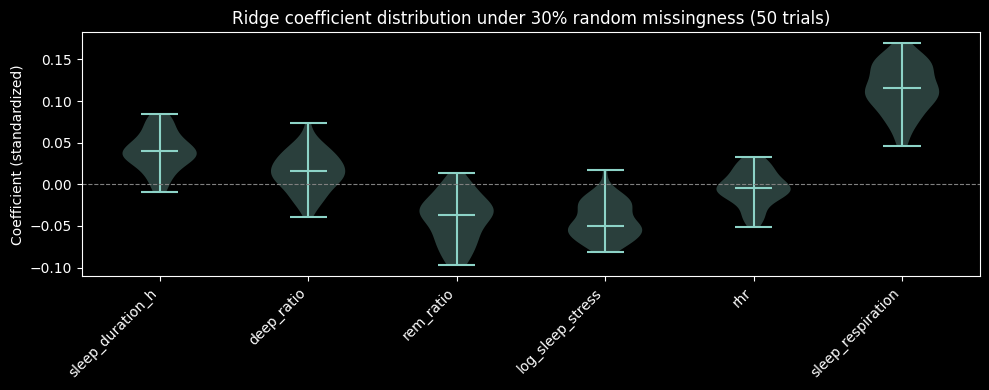

In [12]:
# ── Stability test ────────────────────────────────────────────────────────
# seed=42 is intentional: reproducibility across runs. When new data is added,
# re-run this cell to check whether the stability picture has changed.
rng         = np.random.default_rng(seed=42)
coef_matrix = np.zeros((N_STABILITY_TRIALS, len(FEATURE_COLS)))
n_keep      = int(len(train_df) * (1 - STABILITY_DROP_FRAC))

for trial in range(N_STABILITY_TRIALS):
    # Random subset of training indices — no replacement
    keep_idx = np.sort(rng.choice(len(train_df), size=n_keep, replace=False))
    Xt = X_train_s[keep_idx]
    yt = y_train[keep_idx]
    # Use the same alpha selected by RidgeCV — testing coefficient stability, not alpha
    m = Ridge(alpha=ridge.alpha_)
    m.fit(Xt, yt)
    coef_matrix[trial] = m.coef_

coef_df   = pd.DataFrame(coef_matrix, columns=FEATURE_COLS)
coef_mean = coef_df.mean()
coef_std  = coef_df.std()
# CV = std / |mean|; nan if mean ≈ 0 (near-zero coefficient)
coef_cv   = (coef_std / coef_mean.abs().replace(0, np.nan)).abs()

print(f'Stability test: {N_STABILITY_TRIALS} trials, {STABILITY_DROP_FRAC:.0%} random drop from {len(train_df)} training nights')
print(f'Each trial retains {n_keep} nights.')
print(f'\nCoefficient CV under simulated missingness:')
print(f'  Threshold: ✓<0.30  ~0.30-0.60  ✗>0.60')
for col in FEATURE_COLS:
    cv_val = coef_cv[col]
    if pd.isna(cv_val):
        flag = '?  (mean ≈ 0)'
    elif cv_val > 0.60:
        flag = '✗ FRAGILE'
    elif cv_val > 0.30:
        flag = '~  moderate'
    else:
        flag = '✓  stable'
    mean_val = coef_mean[col]
    print(f'  {flag:14s}  {col:30s}  mean={mean_val:+.4f}  CV={cv_val:.3f}')

# ── Coefficient distribution plot ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
positions = range(len(FEATURE_COLS))
ax.violinplot([coef_df[col].values for col in FEATURE_COLS], positions=positions, showmedians=True)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xticks(list(positions))
ax.set_xticklabels(FEATURE_COLS, rotation=45, ha='right')
ax.set_ylabel('Coefficient (standardized)')
ax.set_title(f'Ridge coefficient distribution under {STABILITY_DROP_FRAC:.0%} random missingness ({N_STABILITY_TRIALS} trials)')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'sleep_stability_test.png'), dpi=120, bbox_inches='tight')
plt.show()

## 6. Output Contract

`compute_sleep_readiness()` is the production function consumed by `intelligence/recovery.py`
and ultimately `intelligence/recommend.py`.

**Three-path design (SC-validated):**
- **Path A** — ≥50% nights present in trailing 30 days → full modifier, weight=1.0
- **Path B** — >0% but <50% coverage → modifier active but downweighted linearly (0% → 0.0 weight, 50% → 1.0 weight)
- **Path C** — zero nights in trailing 30 days → modifier excluded; check-in is the only recovery signal

Missing nights are never imputed. The function uses only data strictly before `target_date`
to prevent production data leakage. Message field reports component availability so the
dashboard can tell the user which signals contributed.

In [13]:
def compute_sleep_readiness(
    target_date: pd.Timestamp,
    sleep_history: pd.DataFrame,
    daily_signals: pd.DataFrame,
    rolling_window: int = 30,
    min_periods: int = 7,
    data_confidence_threshold: float = 0.50,
    architecture_weight: float = 0.60,
    stress_weight: float = 0.40,
) -> dict:
    """
    Compute sleep readiness modifier for a given date.

    Uses only data strictly before target_date (no data leakage in production).
    Designed to be called daily by intelligence/recovery.py after sleep sync.

    Parameters
    ----------
    target_date               : date for which readiness is computed (typically today)
    sleep_history             : full sleep.parquet DataFrame; all columns present
    daily_signals             : full daily_signals.parquet DataFrame; must contain 'rhr'
    rolling_window            : trailing window size in days (default 30)
    min_periods               : minimum nights for a valid z-score (default 7)
    data_confidence_threshold : coverage fraction below which modifier is downweighted (default 0.50)
    architecture_weight       : weight for architecture score in composite (default 0.60)
    stress_weight             : weight for stress score in composite (default 0.40)

    Returns
    -------
    dict:
        path                  : 'A' | 'B' | 'C'
        sleep_readiness_score : float | None  — composite in σ units
        architecture_score    : float | None
        stress_score          : float | None
        data_confidence       : float  — fraction of nights present in trailing window (0–1)
        modifier_weight       : float  — 1.0 (A), scaled (B), 0.0 (C)
        message               : str    — human-readable status for dashboard / narrative
    """
    target_date = pd.Timestamp(target_date)

    # Restrict to history strictly before target_date
    history = sleep_history[sleep_history['date'] < target_date].copy()
    history = history.merge(
        daily_signals[['date', 'rhr']].rename(columns={'rhr': 'rhr_daily'}),
        on='date', how='left'
    )
    # Prefer sleep-file rhr if present; fall back to daily_signals rhr
    if 'rhr' not in history.columns:
        history['rhr'] = history['rhr_daily']
    history = history.sort_values('date').reset_index(drop=True)

    # Trailing window for baseline
    window_start  = target_date - pd.Timedelta(days=rolling_window)
    window_nights = history[history['date'] >= window_start]
    data_confidence = len(window_nights) / rolling_window

    # Path C: no data at all in trailing window
    if len(window_nights) == 0:
        return {
            'path': 'C',
            'sleep_readiness_score': None,
            'architecture_score': None,
            'stress_score': None,
            'data_confidence': 0.0,
            'modifier_weight': 0.0,
            'message': (
                'No sleep data in the trailing 30 days. '
                'Recovery recommendation based on check-in only. '
                'Wear your watch at night to activate the sleep baseline.'
            ),
        }

    def _rolling_z(series: pd.Series, value: float) -> float | None:
        """Z-score of value against the provided trailing window series."""
        valid = series.dropna()
        if len(valid) < min_periods or pd.isna(value):
            return None
        mu    = valid.mean()
        sigma = valid.std(ddof=1)
        if sigma == 0 or pd.isna(sigma):
            return None
        return float((value - mu) / sigma)

    # Last night (most recent before target_date)
    last = history.iloc[-1]

    # Zero-REM guard: treat as missing rather than true zero
    rem_h = (
        float(last['rem_h'])
        if not (last['rem_h'] == 0 and last['sleep_duration_h'] > 3.0)
        else np.nan
    )
    duration_h = float(last['sleep_duration_h']) if last['sleep_duration_h'] > 0 else np.nan
    deep_ratio  = (float(last['deep_h']) / duration_h) if duration_h else np.nan
    rem_ratio   = (rem_h / duration_h) if (duration_h and not pd.isna(rem_h)) else np.nan
    log_stress  = float(np.log1p(last['sleep_stress'])) if not pd.isna(last['sleep_stress']) else np.nan

    # Historical series for rolling baseline (window only)
    hist_deep_ratio  = (window_nights['deep_h'] / window_nights['sleep_duration_h']).replace([np.inf, -np.inf], np.nan)
    hist_rem_ratio   = (window_nights['rem_h']  / window_nights['sleep_duration_h']).replace([np.inf, -np.inf], np.nan)
    hist_log_stress  = np.log1p(window_nights['sleep_stress'].dropna())
    hist_rhr         = window_nights['rhr'].dropna() if 'rhr' in window_nights else pd.Series(dtype=float)
    hist_respiration = window_nights['sleep_respiration'].dropna() if 'sleep_respiration' in window_nights else pd.Series(dtype=float)
    hist_duration    = window_nights['sleep_duration_h'].dropna()

    # Architecture z-scores (positive orientation)
    duration_z   = _rolling_z(hist_duration,   duration_h)
    deep_ratio_z = _rolling_z(hist_deep_ratio, deep_ratio)
    rem_ratio_z  = _rolling_z(hist_rem_ratio,  rem_ratio)

    arch_components = [z for z in [duration_z, deep_ratio_z, rem_ratio_z] if z is not None]
    architecture_score = float(np.mean(arch_components)) if arch_components else None

    # Stress z-scores (inverted: high raw = worse = negative modifier)
    stress_z = (
        -_rolling_z(hist_log_stress,  log_stress)
        if not pd.isna(log_stress) and _rolling_z(hist_log_stress, log_stress) is not None
        else None
    )
    rhr_z = (
        -_rolling_z(hist_rhr, float(last['rhr']))
        if 'rhr' in last and not pd.isna(last['rhr']) and _rolling_z(hist_rhr, float(last['rhr'])) is not None
        else None
    )
    resp_z = (
        -_rolling_z(hist_respiration, float(last['sleep_respiration']))
        if 'sleep_respiration' in last and not pd.isna(last['sleep_respiration'])
           and _rolling_z(hist_respiration, float(last['sleep_respiration'])) is not None
        else None
    )

    stress_components = [z for z in [stress_z, rhr_z, resp_z] if z is not None]
    stress_score = float(np.mean(stress_components)) if stress_components else None

    # Composite readiness — fall back gracefully if one group is entirely missing
    if architecture_score is not None and stress_score is not None:
        readiness = architecture_weight * architecture_score + stress_weight * stress_score
    elif architecture_score is not None:
        readiness = float(architecture_score)
    elif stress_score is not None:
        readiness = float(stress_score)
    else:
        readiness = None

    # Path A vs B based on data_confidence
    if data_confidence >= data_confidence_threshold:
        path = 'A'
        modifier_weight = 1.0
        message = (
            f'Sleep modifier active (confidence {data_confidence:.0%}, '
            f'last night score {int(last["sleep_score"]) if not pd.isna(last["sleep_score"]) else "N/A"}). '
            f'Architecture: {len(arch_components)}/3 components. '
            f'Stress: {len(stress_components)}/3 components.'
        )
    else:
        path = 'B'
        modifier_weight = data_confidence / data_confidence_threshold
        message = (
            f'Sparse sleep data ({data_confidence:.0%} coverage, '
            f'threshold {data_confidence_threshold:.0%}). '
            f'Modifier downweighted to {modifier_weight:.0%}. '
            f'Architecture: {len(arch_components)}/3. '
            f'Stress: {len(stress_components)}/3.'
        )

    return {
        'path': path,
        'sleep_readiness_score': round(readiness, 4) if readiness is not None else None,
        'architecture_score': round(architecture_score, 4) if architecture_score is not None else None,
        'stress_score': round(stress_score, 4) if stress_score is not None else None,
        'data_confidence': round(data_confidence, 4),
        'modifier_weight': round(modifier_weight, 4),
        'message': message,
    }

In [14]:
# ── Example output: run the function on recent dates ──────────────────────
print('Example output — last 5 available dates:\n')

# Use the last 5 dates that have sleep data
recent_dates = sorted(df_sleep['date'].dropna().unique())[-5:]

for d in recent_dates:
    result = compute_sleep_readiness(
        target_date   = d + pd.Timedelta(days=1),  # score for the morning after this night
        sleep_history = df_sleep,
        daily_signals = df_daily,
    )
    print(f"Date: {pd.Timestamp(d).date()}  →  readiness morning: {pd.Timestamp(d + pd.Timedelta(days=1)).date()}")
    print(f"  Path              : {result['path']}")
    print(f"  sleep_readiness   : {result['sleep_readiness_score']}")
    print(f"  architecture      : {result['architecture_score']}")
    print(f"  stress            : {result['stress_score']}")
    print(f"  data_confidence   : {result['data_confidence']:.2f}")
    print(f"  modifier_weight   : {result['modifier_weight']:.2f}")
    print(f"  message           : {result['message']}")
    print()

Example output — last 5 available dates:

Date: 2026-04-14  →  readiness morning: 2026-04-15
  Path              : A
  sleep_readiness   : -1.3416
  architecture      : -1.3439
  stress            : -1.338
  data_confidence   : 0.87
  modifier_weight   : 1.00
  message           : Sleep modifier active (confidence 87%, last night score 29). Architecture: 3/3 components. Stress: 3/3 components.

Date: 2026-04-15  →  readiness morning: 2026-04-16
  Path              : A
  sleep_readiness   : 0.0347
  architecture      : 0.1053
  stress            : -0.0711
  data_confidence   : 0.87
  modifier_weight   : 1.00
  message           : Sleep modifier active (confidence 87%, last night score 81). Architecture: 3/3 components. Stress: 3/3 components.

Date: 2026-04-16  →  readiness morning: 2026-04-17
  Path              : A
  sleep_readiness   : -0.2583
  architecture      : -0.3666
  stress            : -0.0959
  data_confidence   : 0.87
  modifier_weight   : 1.00
  message           : Sleep 

## 7. Implementation Notes

### Integration with `intelligence/recovery.py`

The `compute_sleep_readiness()` function is the production contract. Integration:

```python
# In intelligence/recovery.py — call after each Garmin sync
sleep_result = compute_sleep_readiness(
    target_date   = today,
    sleep_history = await sleep_repo.get_all(user_id),
    daily_signals = await workout_repo.get_daily_signals(user_id),
)
# sleep_result['sleep_readiness_score'] is the modifier fed into recommend.py
# sleep_result['modifier_weight'] scales it before combining with HRV z-score and TSB
```

### Recommendation engine integration (three-path)

| Path | Coverage | Engine behaviour |
|---|---|---|
| A | ≥50% | Full sleep modifier applied at weight=1.0 |
| B | 0–50% | Modifier included but downweighted linearly |
| C | 0% | Sleep modifier excluded; check-in is the primary recovery signal |

On Path C the engine should widen the recommendation band — prescribe a zone range
rather than a specific zone, and surface `message` to the user in the dashboard.

### Ridge model weights → composite update

Once the Ridge model coefficients are validated (stable CV across stability trials,
expected signs confirmed), update `ARCHITECTURE_WEIGHT` and `STRESS_WEIGHT` by
deriving them from the Ridge coefficients:

```python
# Split Ridge coefficients into architecture vs stress groups
# and normalise within each group → group weight in the composite
arch_sum   = sum(abs(c) for col, c in zip(FEATURE_COLS, ridge.coef_) if col in ARCH_COLS)
stress_sum = sum(abs(c) for col, c in zip(FEATURE_COLS, ridge.coef_) if col in STRESS_COLS)
total      = arch_sum + stress_sum
ARCHITECTURE_WEIGHT = arch_sum / total
STRESS_WEIGHT       = stress_sum / total
```

### Decay constants (from BASELINE_ROADMAP.md)

The sleep readiness signal decays over the day — it reflects last night's sleep, not a
persistent state. The app currently applies it as a same-day modifier only. No explicit
decay function is needed until the plan-to-actual loop is wired (required before any sleep
signal is used as a hard modifier in `recommend.py`).

### What this notebook does NOT build
- **HRV-strain 48h underperformance prediction** — requires outcome labels not in the dataset
- **Sleep debt accumulation model** — requires longer-term labels (injury, illness) not yet available
- **Cross-athlete generalisation** — this is a personal baseline; coefficients are athlete-specific